# Inspect patient 50122488 — LV + scar orientation

Renders LV shell + core zone from 6 viewpoints using the same PyVista approach as the 3-D grid in `01_scar_exploration` (view_isometric + azimuth variants). Goal: diagnose why this patient shows different orientation in the grid.

In [22]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
from src.data_loading import scan

HD_ROOT   = r"F:/RM_TEKNON_DEVELOP"
TARGET_ID = "50122488"
WIN       = (500, 440)

In [23]:
all_cases = scan(HD_ROOT)
matches   = [c for c in all_cases if c.patient_id == TARGET_ID]

if not matches:
    raise RuntimeError(f"Patient {TARGET_ID} not found")

case = matches[0]
print(case)

[2024] 50122488 | anatomy 4/4  tissue 5/5  layers 9  CSVs 6


In [24]:
def _best_shell(c):
    for key in ("lv", "myocardium", "endo", "epi"):
        p = c.anatomy.get(key)
        if p is not None and p.exists():
            return pv.read(str(p))
    return None

def _get_cz(c):
    p = c.tissue_surfaces.get("core")
    if p is None or not p.exists():
        return None
    return pv.read(str(p))

cz    = _get_cz(case)
shell = _best_shell(case)

if cz is None:
    raise RuntimeError(f"No core-zone mesh for {TARGET_ID}")

print(f"CZ   bounds : {np.round(cz.bounds, 1)}")
print(f"CZ   center : {np.round(cz.center, 1)}")
if shell is not None:
    print(f"LV   bounds : {np.round(shell.bounds, 1)}")
    print(f"LV   center : {np.round(shell.center, 1)}")
    pts = np.array(shell.points)
    _, _, Vt = np.linalg.svd(pts - pts.mean(0), full_matrices=False)
    print(f"LV PCA axis0: {np.round(Vt[0], 3)}  (long axis direction)")

CZ   bounds : [ 37.4 119.4 -71.8 -29.6  23.2  88.1]
CZ   center : [ 78.4 -50.7  55.6]
LV   bounds : [ 35.7 123.  -77.2  26.   18.   92.4]
LV   center : [ 79.4 -25.6  55.2]
LV PCA axis0: [-0.424  0.905  0.043]  (long axis direction)


## Diagnose PCA long-axis failure\n\nSVD assumes LV is elongated (λ₀ >> λ₁). `Vt[0]` = direction of max variance = supposed long axis. Fails when mesh is near-spherical, has outliers, or extra anatomy shifts first PC.

In [25]:
# ── 1. SVD eigenvalue ratio ───────────────────────────────────────────────────
# If λ0/λ1 ≈ 1 → PCA can't reliably separate long axis from a transverse axis.
# Healthy LV → ratio typically 3-6x. Near-spherical or extra anatomy → ratio < 2.

pts    = np.array(shell.points)
center = pts.mean(axis=0)
_, sv, Vt = np.linalg.svd(pts - center, full_matrices=False)
ev = sv**2  # proportional to variance along each PC

print("Singular values :", np.round(sv, 2))
print("Variance ratios  :", np.round(ev / ev.sum(), 3))
print(f"λ0/λ1 ratio      : {ev[0]/ev[1]:.2f}  (healthy LV ≈ 3-6)")
print()
print(f"PC0 direction    : {np.round(Vt[0], 3)}  ← claimed long axis")
print(f"PC1 direction    : {np.round(Vt[1], 3)}")
print(f"PC2 direction    : {np.round(Vt[2], 3)}")

# Apex = point with min projection along PC0
proj0  = (pts - center) @ Vt[0]
apex   = pts[proj0.argmin()]
print(f"\nDetected apex    : {np.round(apex, 1)}")
print(f"Mesh center      : {np.round(center, 1)}")
print(f"Apex→center vec  : {np.round(center - apex, 1)}  (should roughly align with PC0)")

Singular values : [2660.38 2172.9  2025.13]
Variance ratios  : [0.445 0.297 0.258]
λ0/λ1 ratio      : 1.50  (healthy LV ≈ 3-6)

PC0 direction    : [-0.424  0.905  0.043]  ← claimed long axis
PC1 direction    : [-0.049  0.024 -0.999]
PC2 direction    : [-0.904 -0.425  0.034]

Detected apex    : [108.1 -75.3  42.1]
Mesh center      : [ 61.6 -15.1  57.4]
Apex→center vec  : [-46.5  60.2  15.4]  (should roughly align with PC0)


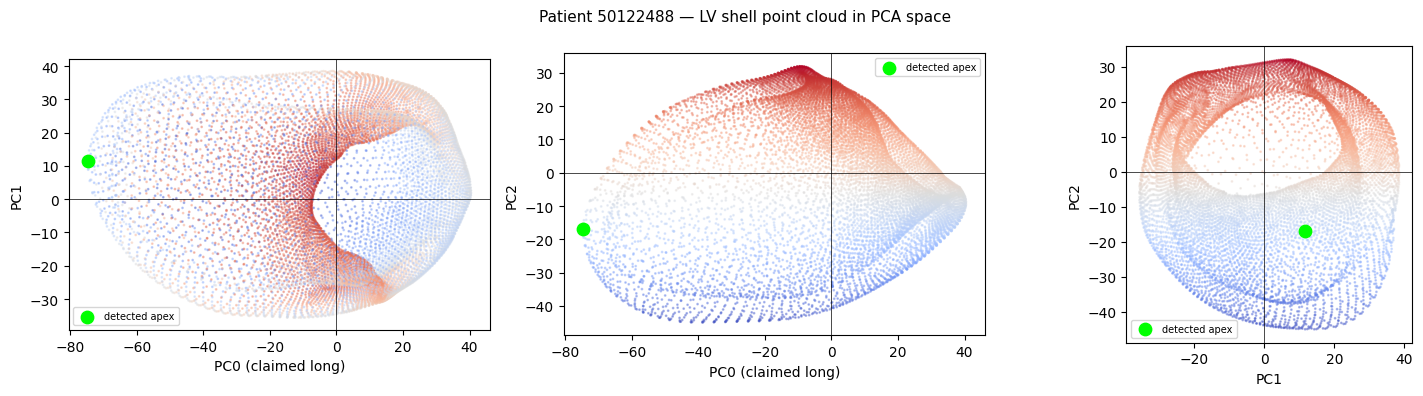

In [26]:
# ── 2. Point-cloud projections onto each PC pair ─────────────────────────────
# PC0 vs PC1 should show an elongated rugby-ball → confirms PC0 = long axis.
# If near-circular → λ0≈λ1, axis ambiguous.
# Colour by PC2 projection to see 3-D structure.

proj1 = (pts - center) @ Vt[1]
proj2 = (pts - center) @ Vt[2]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pairs = [
    ("PC0 (claimed long)", "PC1", proj0, proj1),
    ("PC0 (claimed long)", "PC2", proj0, proj2),
    ("PC1",               "PC2", proj1, proj2),
]
for ax, (xl, yl, x, y) in zip(axes, pairs):
    sc = ax.scatter(x, y, c=proj2, cmap="coolwarm", s=1, alpha=0.4)
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_aspect("equal")
    ax.axhline(0, lw=0.5, c="k"); ax.axvline(0, lw=0.5, c="k")
    # mark detected apex
    ax_idx = [proj0, proj1, proj2]
    ax.scatter([ax_idx[["PC0 (claimed long)","PC1","PC2"].index(xl)][proj0.argmin()]],
               [ax_idx[["PC0 (claimed long)","PC1","PC2"].index(yl)][proj0.argmin()]],
               c="lime", s=80, zorder=5, label="detected apex")
    ax.legend(fontsize=7)
plt.suptitle(f"Patient {TARGET_ID} — LV shell point cloud in PCA space", fontsize=11)
plt.tight_layout()
plt.show()

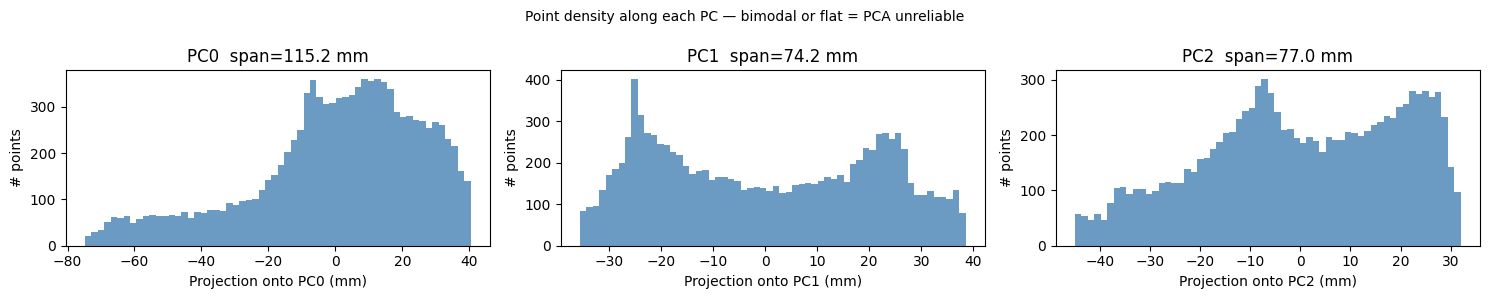


World-axis bounding-box spans:
  X: 87.3 mm
  Y: 103.2 mm
  Z: 74.4 mm
  → longest world axis should match PC0 if mesh well-oriented


In [27]:
# ── 3. Point density along each PC ───────────────────────────────────────────
# Long axis should have roughly uniform density with a taper at apex end.
# Suspicious: bimodal distribution (two clusters), or flat (spherical mesh).
# Also check world-axis bounding-box spans — which world axis is longest?

fig, axes = plt.subplots(1, 3, figsize=(15, 3))
for ax, (lbl, proj) in zip(axes, [("PC0",proj0),("PC1",proj1),("PC2",proj2)]):
    ax.hist(proj, bins=60, color="steelblue", alpha=0.8)
    ax.set_xlabel(f"Projection onto {lbl} (mm)")
    ax.set_ylabel("# points")
    ax.set_title(f"{lbl}  span={proj.max()-proj.min():.1f} mm")
plt.suptitle("Point density along each PC — bimodal or flat = PCA unreliable", fontsize=10)
plt.tight_layout()
plt.show()

print("\nWorld-axis bounding-box spans:")
for i, ax_lbl in enumerate("XYZ"):
    span = pts[:, i].max() - pts[:, i].min()
    print(f"  {ax_lbl}: {span:.1f} mm")
print("  → longest world axis should match PC0 if mesh well-oriented")

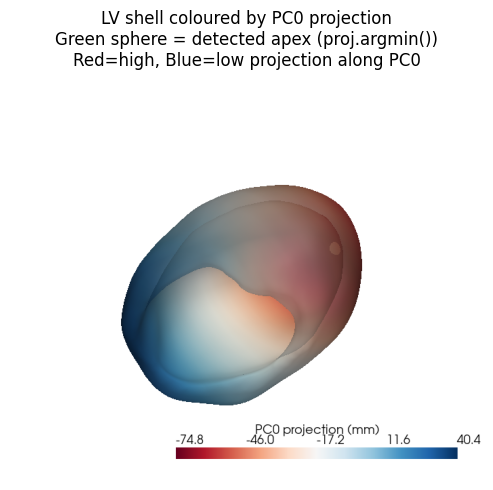

In [28]:
# ── 4. PyVista render coloured by PC0 projection ─────────────────────────────
# Red = one end, blue = other. Apex (smallest proj) should be at the pointy tip.
# If colour gradient runs sideways → PC0 is a transverse axis, not long axis.

shell_col = shell.copy()
shell_col["pc0"] = (pts - center) @ Vt[0]

pl = pv.Plotter(off_screen=True, window_size=(700, 600))
pl.set_background("white")
pl.add_mesh(shell_col, scalars="pc0", cmap="RdBu", opacity=0.85,
            smooth_shading=True, show_scalar_bar=True,
            scalar_bar_args={"title": "PC0 projection (mm)"})
# mark apex as a sphere
pl.add_mesh(pv.Sphere(radius=3, center=apex), color="lime")
pl.view_isometric()
pl.camera.azimuth += 120
img = pl.screenshot(None, return_img=True)
pl.close()

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(img); ax.axis("off")
ax.set_title(f"LV shell coloured by PC0 projection\n"
             f"Green sphere = detected apex (proj.argmin())\n"
             f"Red=high, Blue=low projection along PC0")
plt.tight_layout()
plt.show()

Long axis in world space : [-0.424  0.905  0.043]
Angle from Z-axis (deg)  : 87.5°
  → 0° = perfectly vertical in world space (like most patients)
  → large angle = mesh stored in rotated orientation → looks tilted in grid


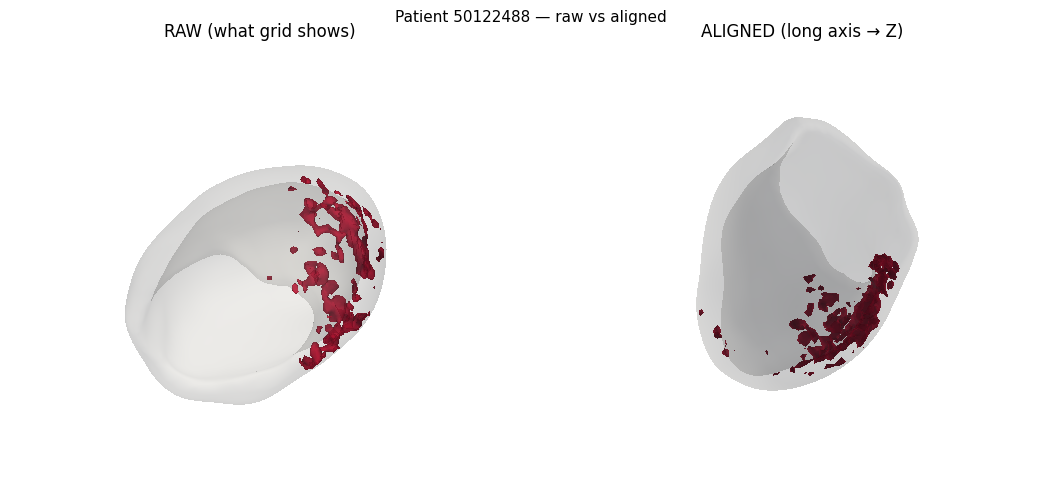

In [29]:
# ── 5. Raw vs aligned side-by-side ───────────────────────────────────────────
# Grid notebook renders raw world coords. No _compute_transform applied.
# Here: left = raw (what grid shows), right = after aligning long axis to +Z.
# If they differ → world-space orientation is the culprit, not PCA failure.

def _compute_transform(lv_mesh):
    p      = np.array(lv_mesh.points)
    c      = p.mean(axis=0)
    _, _, V = np.linalg.svd(p - c, full_matrices=False)
    axis   = V[0]
    proj   = (p - c) @ axis
    apx    = p[proj.argmin()]
    if np.dot(c - apx, axis) < 0:
        axis = -axis
    z  = np.array([0., 0., 1.])
    v  = np.cross(axis, z)
    s  = np.linalg.norm(v)
    co = np.dot(axis, z)
    if s < 1e-6:
        R = np.eye(3)
    else:
        vx = np.array([[0,-v[2],v[1]],[v[2],0,-v[0]],[-v[1],v[0],0]])
        R  = np.eye(3) + vx + vx @ vx * ((1 - co) / s**2)
    return R, apx

R, apx = _compute_transform(shell)
long_axis_world = Vt[0] if np.dot(Vt[0], np.array([0,0,1])) >= 0 else -Vt[0]
print(f"Long axis in world space : {np.round(long_axis_world, 3)}")
print(f"Angle from Z-axis (deg)  : {np.degrees(np.arccos(np.clip(abs(np.dot(long_axis_world,[0,0,1])),0,1))):.1f}°")
print("  → 0° = perfectly vertical in world space (like most patients)")
print("  → large angle = mesh stored in rotated orientation → looks tilted in grid")

def _render(mesh_list, transform=None, label="", azimuth=120):
    pl = pv.Plotter(off_screen=True, window_size=(500, 440))
    pl.set_background("white")
    for m, color, opacity in mesh_list:
        mc = m.copy()
        if transform is not None:
            R_, apx_ = transform
            mc.points = (np.array(m.points) - apx_) @ R_.T
        pl.add_mesh(mc, color=color, opacity=opacity,
                    smooth_shading=True, show_scalar_bar=False)
    pl.view_isometric()
    pl.camera.azimuth += azimuth
    img = pl.screenshot(None, return_img=True)
    pl.close()
    return img

meshes = [(shell, "#cccccc", 0.15), (cz, "crimson", 0.95)]
img_raw     = _render(meshes, transform=None,       label="raw")
img_aligned = _render(meshes, transform=(R, apx),   label="aligned")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(img_raw);     axes[0].set_title("RAW (what grid shows)");          axes[0].axis("off")
axes[1].imshow(img_aligned); axes[1].set_title("ALIGNED (long axis → Z)");        axes[1].axis("off")
plt.suptitle(f"Patient {TARGET_ID} — raw vs aligned", fontsize=11)
plt.tight_layout()
plt.show()

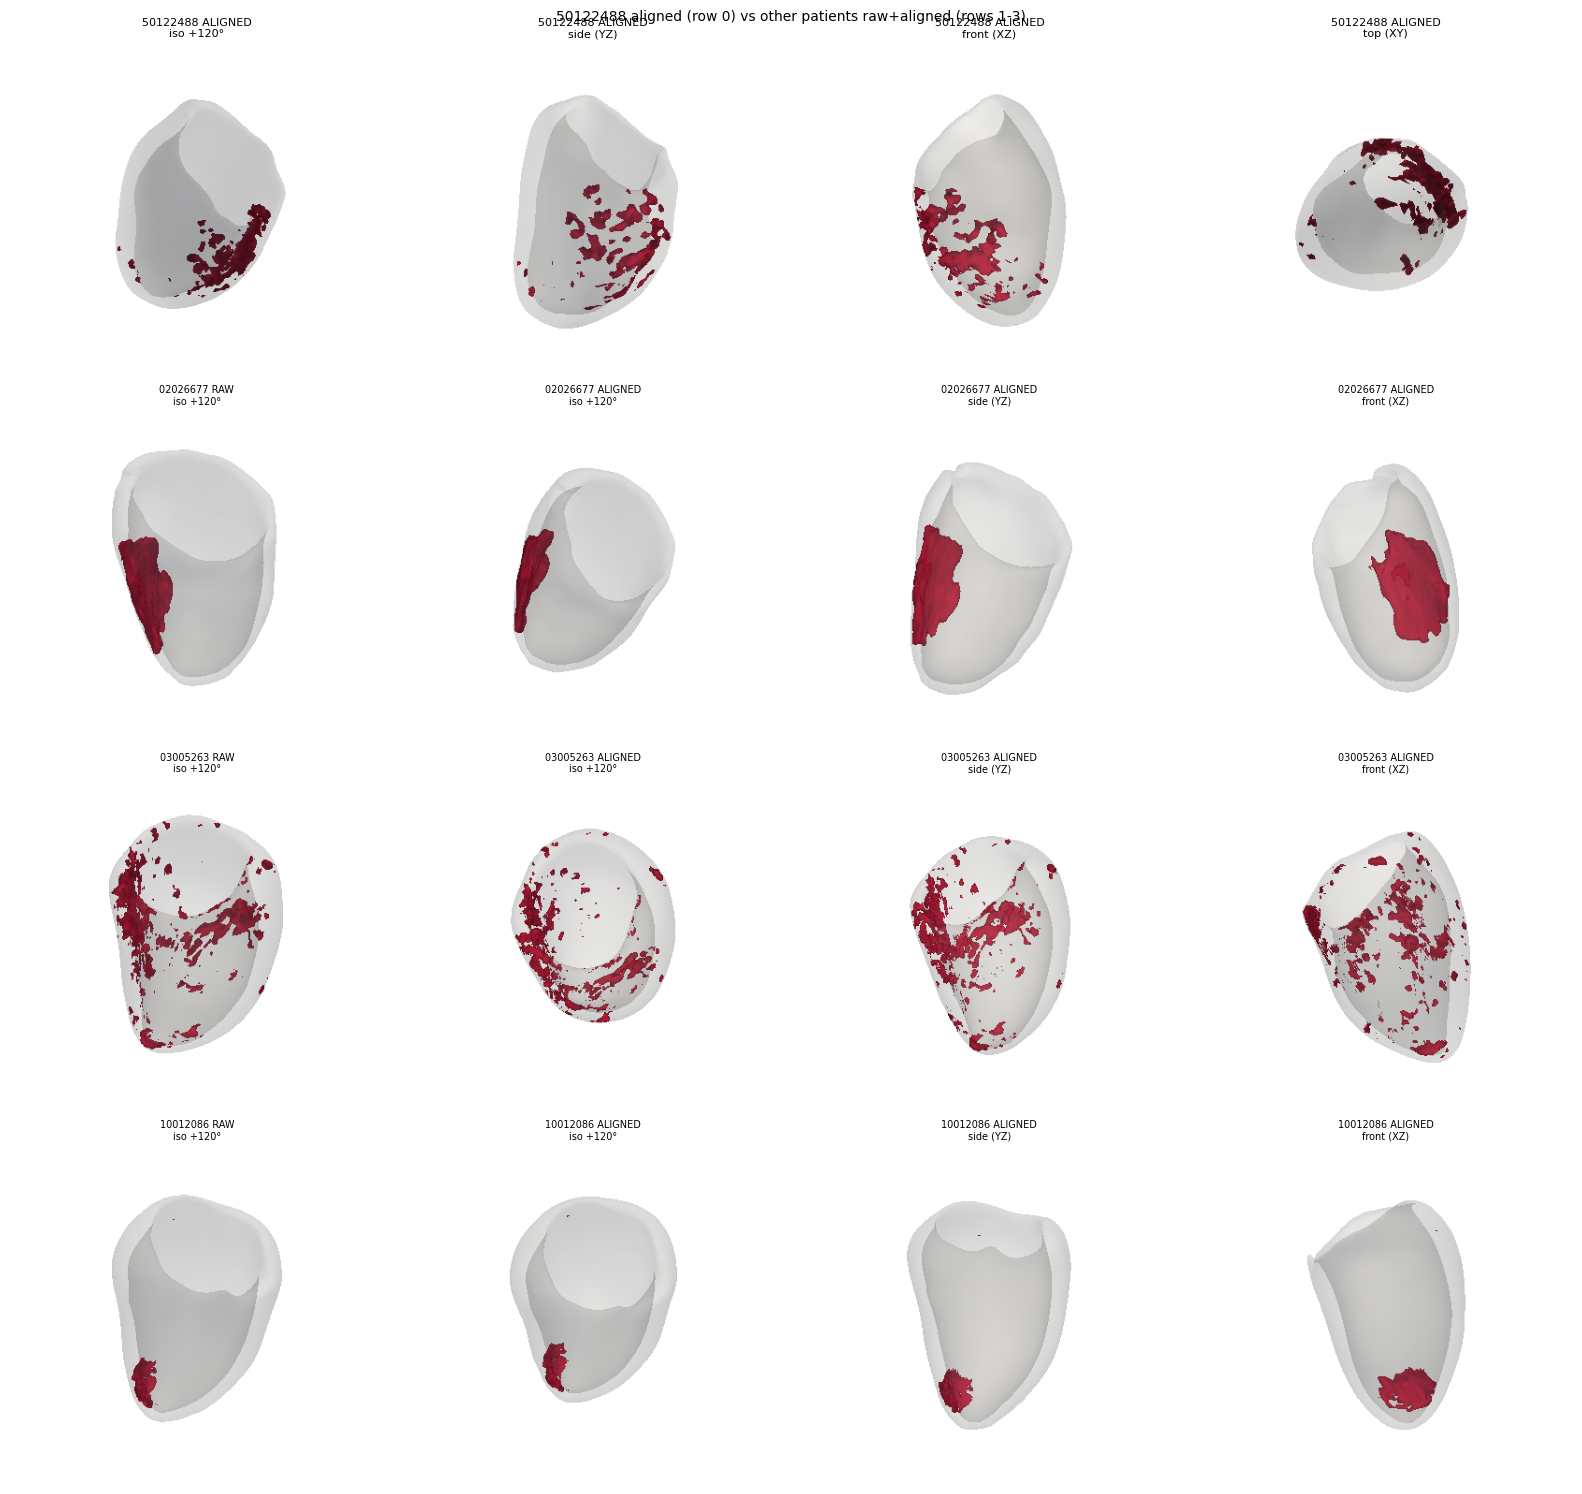

In [30]:
# ── 6. Aligned from proper side views + compare other patients (raw) ──────────
# After align → Z, look from side (elev=0) so apex at bottom, base at top.
# Also render 3 other patients raw to see if THEY look different.

def _render_views(mesh_list, transform=None, views=None):
    """Returns list of (label, img)."""
    if views is None:
        views = [
            ("iso +120°",   dict(isometric=True),   120),
            ("side (YZ)",   dict(vector=(-1,0,0)),     0),
            ("front (XZ)",  dict(vector=(0,-1,0)),     0),
            ("top (XY)",    dict(vector=(0,0,-1)),      0),
        ]
    imgs = []
    for label, vkw, az in views:
        pl = pv.Plotter(off_screen=True, window_size=(400, 360))
        pl.set_background("white")
        for m, col, op in mesh_list:
            mc = m.copy()
            if transform is not None:
                R_, apx_ = transform
                mc.points = (np.array(m.points) - apx_) @ R_.T
            pl.add_mesh(mc, color=col, opacity=op,
                        smooth_shading=True, show_scalar_bar=False)
        if vkw.get("isometric"):
            pl.view_isometric()
        else:
            pl.view_vector(vkw["vector"])
        pl.camera.azimuth += az
        imgs.append((label, pl.screenshot(None, return_img=True)))
        pl.close()
    return imgs

# Patient 50122488 aligned — 4 views
aligned_imgs = _render_views(meshes, transform=(R, apx))

# 3 other patients raw (first 3 from all_cases that have both shell + CZ)
other_cases = [c for c in all_cases
               if c.patient_id != TARGET_ID
               and _best_shell(c) is not None
               and _get_cz(c) is not None][:3]

side_view = [("side (YZ)", dict(vector=(-1,0,0)), 0)]

ncols = 4
nrows = 1 + len(other_cases)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3.8))

# row 0: patient 50122488 aligned
for ax, (lbl, img) in zip(axes[0], aligned_imgs):
    ax.imshow(img); ax.set_title(f"50122488 ALIGNED\n{lbl}", fontsize=8); ax.axis("off")

# rows 1-3: other patients raw, same 4 views
for row, other in enumerate(other_cases, start=1):
    sh  = _best_shell(other)
    czz = _get_cz(other)
    om  = [(sh, "#cccccc", 0.15), (czz, "crimson", 0.95)]
    R2, apx2 = _compute_transform(sh)
    # show raw iso + aligned side for comparison
    raw_iso  = _render_views(om, transform=None,         views=[("iso +120°", dict(isometric=True), 120)])[0]
    aln_views = _render_views(om, transform=(R2, apx2),
                              views=[("iso +120°",dict(isometric=True),120),
                                     ("side (YZ)",dict(vector=(-1,0,0)),0),
                                     ("front (XZ)",dict(vector=(0,-1,0)),0)])
    all_v = [raw_iso] + aln_views
    for ax, (lbl, img) in zip(axes[row], all_v):
        ax.imshow(img)
        ax.set_title(f"{other.patient_id} {'RAW' if lbl=='iso +120°' and ax==axes[row][0] else 'ALIGNED'}\n{lbl}", fontsize=7)
        ax.axis("off")

plt.suptitle("50122488 aligned (row 0) vs other patients raw+aligned (rows 1-3)", fontsize=10)
plt.tight_layout()
plt.show()

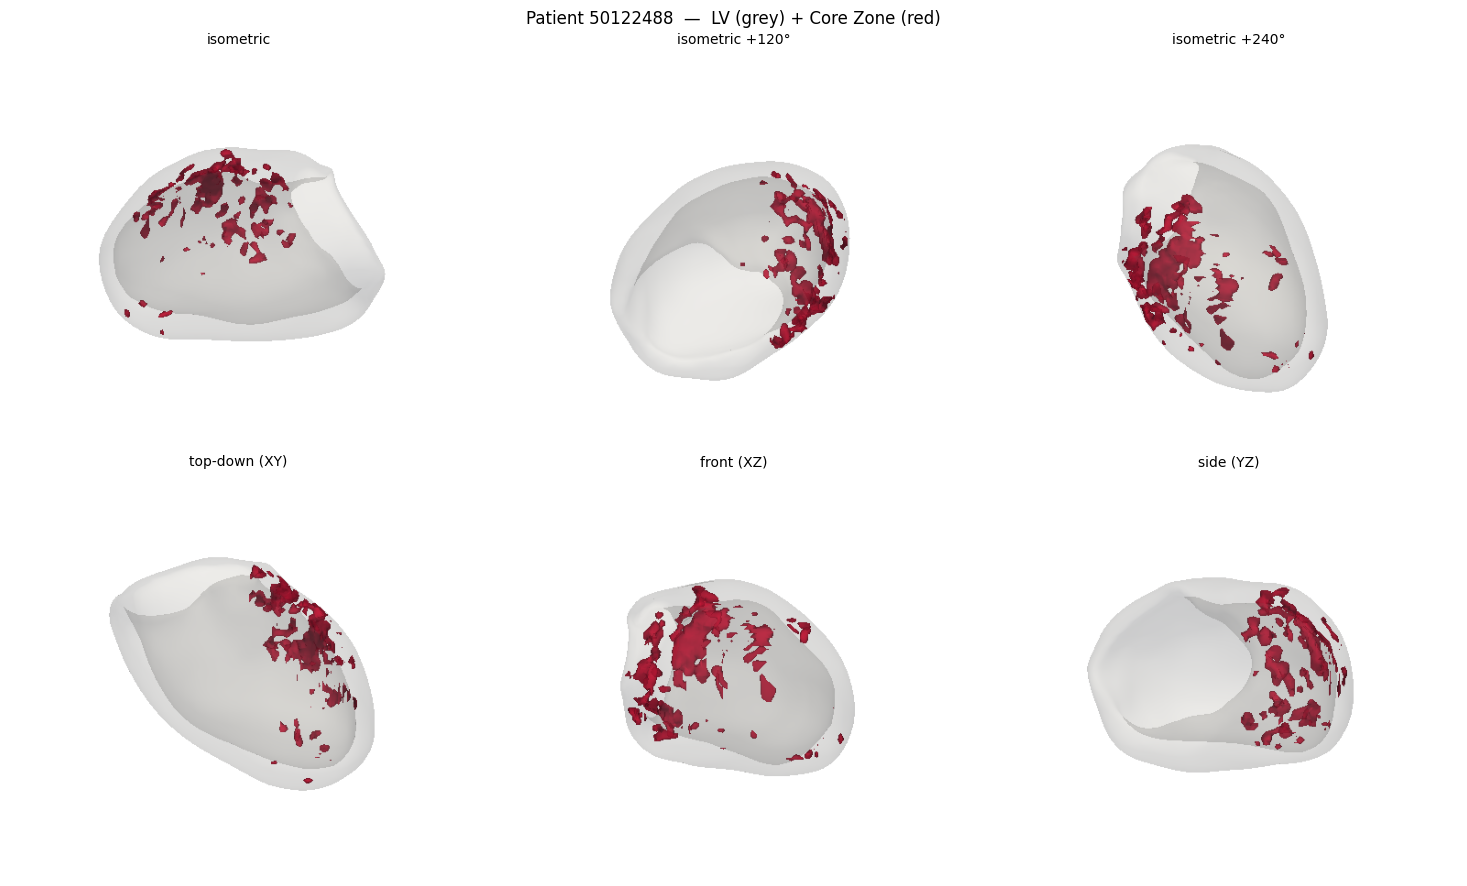

In [31]:
VIEWS = [
    ("isometric",       "isometric",  0),
    ("isometric +120°", "isometric", 120),
    ("isometric +240°", "isometric", 240),
    ("top-down (XY)",   (0, 0, -1),   0),
    ("front (XZ)",      (0, -1, 0),   0),
    ("side (YZ)",       (-1, 0, 0),   0),
]

imgs = []
for label, view, extra_az in VIEWS:
    pl = pv.Plotter(off_screen=True, window_size=WIN)
    pl.set_background("white")
    if shell is not None:
        pl.add_mesh(shell, color="#cccccc", opacity=0.15,
                    smooth_shading=True, show_scalar_bar=False)
    pl.add_mesh(cz, color="crimson", opacity=0.95,
                smooth_shading=True, show_scalar_bar=False)
    if view == "isometric":
        pl.view_isometric()
    else:
        pl.view_vector(view)
    if extra_az:
        pl.camera.azimuth += extra_az
    imgs.append((label, pl.screenshot(None, return_img=True)))
    pl.close()

ncols = 3
nrows = int(np.ceil(len(imgs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4.5))
axes = axes.flatten()

for ax, (label, img) in zip(axes, imgs):
    ax.imshow(img)
    ax.set_title(label, fontsize=10)
    ax.axis("off")
for ax in axes[len(imgs):]:
    ax.set_visible(False)

fig.suptitle(f"Patient {TARGET_ID}  —  LV (grey) + Core Zone (red)", fontsize=12)
plt.tight_layout()

OUT = ROOT / "results" / "01_scar_exploration"
OUT.mkdir(parents=True, exist_ok=True)
plt.savefig(OUT / f"inspect_{TARGET_ID}_views.png", bbox_inches="tight", dpi=150)
plt.show()